# Mini-Project 1: MovieLens 1M Recommendation System

**Goal:** Build a hybrid recommendation system that combines collaborative filtering (SVD) for warm users with a similar-user strategy (KMeans clustering) for cold-start users, enriched by demographics and genre preferences.

**Dataset:** MovieLens 1M - 1,000,209 ratings (1–5) from 6,040 users on 3,883 movies.

> _Note: The dataset is stored locally._

---

## Table of Contents

1. [Environment Setup & Data Loading](#1-environment-setup--data-loading)
2. [Exploratory Data Analysis (EDA)](#2-exploratory-data-analysis)
3. [Data Preparation for Modeling](#3-data-preprocessing-for-modeling)
4. [SVD Model - Training & Evaluation](#4-svd-model--training--evaluation)
5. [Recommendation Logic](#5-recommendation-logic)
6. [Evaluation & Quality](#6-evaluation--quality)
7. [Justification & Summary](#7-justification--summary)

---
## 1. Environment Setup & Data Loading

We first load the three core files from the MovieLens 1M dataset:
- **./data/raw/ml-1m/ratings.dat** - 1,000,209 ratings (`UserID::MovieID::Rating::Timestamp`)
- **./data/raw/ml-1m/users.dat** - 6,040 user profiles (`UserID::Gender::Age::Occupation::Zip`)
- **./data/raw/ml-1m/movies.dat** - 3,883 movies (`MovieID::Title::Genres`) (genres are pipe-separated strings)

> _Note: More detailed information about the dataset can be found in the README file `./data/raw/ml-1m/README`._

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

from project1.dataset import (
    GENRE_NAMES,
    load_ratings, load_users, load_items,
    load_merged, ratings_to_surprise, surprise_traintest,
    train_test_split_df,
)
from project1.features import compute_genre_preference, build_user_features
from project1.plots import (
    set_style, plot_rating_distribution, plot_ratings_per_user,
    plot_ratings_per_item, plot_age_distribution, plot_gender_distribution,
    plot_occupation_distribution, plot_genre_distribution, plot_genre_in_rated,
    plot_mean_rating_by_genre, plot_sparsity_summary,
)
from project1.modeling.train import (
    train_svd, evaluate_svd, cross_validate_svd,
    train_cold_start_model, save_models, bayesian_optimize_svd,
)
from project1.modeling.predict import (
    get_top_n_for_user, recommend_cold_user,
    precision_recall_at_k, ndcg_at_k, coverage_at_k,
)

set_style()
print("All imports successful.")

2026-03-19 13:12:37.584 | INFO     | project1.config:<module>:11 - PROJ_ROOT path is: /home/ptomco/School/5-year/LS/ISA/ISA_project1_movielens_recsys


All imports successful.


In [2]:
# Load the datasets

ratings = load_ratings()
users = load_users()
items = load_items()

print(f"Ratings: {ratings.shape}")
print(f"Users:   {users.shape}")
print(f"Items:   {items.shape}")

2026-03-19 13:12:42.075 | INFO     | project1.dataset:load_ratings:80 - Loaded 1000209 ratings from ratings.dat
2026-03-19 13:12:42.092 | INFO     | project1.dataset:load_users:100 - Loaded 6040 users from users.dat
2026-03-19 13:12:42.133 | INFO     | project1.dataset:load_items:120 - Loaded 3883 items from movies.dat
Ratings: (1000209, 4)
Users:   (6040, 7)
Items:   (3883, 21)


In [3]:
print("=== Ratings ===")
display(ratings.head())
print(ratings.dtypes)

print("\n=== Users ===")
display(users.head())

print("\n=== Items (first rows with genre columns) ===")
display(items[['item_id', 'title', 'genres_str', 'Action', 'Comedy', 'Drama']].head())

=== Ratings ===


,user_id,item_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


user_id      int64
item_id      int64
rating       int64
timestamp    int64
dtype: object

=== Users ===


,user_id,gender,age_code,occupation_code,zip_code,age_label,occupation
0,1,F,1,10,48067,Under 18,K-12 student
1,2,M,56,16,70072,56+,self-employed
2,3,M,25,15,55117,25-34,scientist
3,4,M,45,7,02460,45-49,executive/managerial
4,5,M,25,20,55455,25-34,writer



=== Items (first rows with genre columns) ===


,item_id,title,genres_str,Action,Comedy,Drama
0,1,Toy Story (1995),Animation|Children's|Comedy,0,1,0
1,2,Jumanji (1995),Adventure|Children's|Fantasy,0,0,0
2,3,Grumpier Old Men (1995),Comedy|Romance,0,1,0
3,4,Waiting to Exhale (1995),Comedy|Drama,0,1,1
4,5,Father of the Bride Part II (1995),Comedy,0,1,0


In [4]:
merged = load_merged(ratings, users, items)
print(f"Merged dataset: {merged.shape}")
display(merged.head())

2026-03-19 13:12:43.161 | INFO     | project1.dataset:load_merged:137 - Merged dataset: 1000209 rows, 30 columns
Merged dataset: (1000209, 30)


,user_id,item_id,rating,timestamp,gender,age_code,occupation_code,zip_code,age_label,occupation,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,1193,5,978300760,F,1,10,48067,Under 18,K-12 student,...,0,0,0,0,0,0,0,0,0,0
1,1,661,3,978302109,F,1,10,48067,Under 18,K-12 student,...,0,0,0,1,0,0,0,0,0,0
2,1,914,3,978301968,F,1,10,48067,Under 18,K-12 student,...,0,0,0,1,0,1,0,0,0,0
3,1,3408,4,978300275,F,1,10,48067,Under 18,K-12 student,...,0,0,0,0,0,0,0,0,0,0
4,1,2355,5,978824291,F,1,10,48067,Under 18,K-12 student,...,0,0,0,0,0,0,0,0,0,0


**Verification:** The dataset has 1,000,209 ratings, 6,040 users, and 3,883 movies - consistent with the MovieLens 1M documentation.

In [5]:
assert len(ratings) == 1000209, f"Expected ~1M ratings, got {len(ratings)}"
assert users['user_id'].nunique() == 6040
assert items['item_id'].nunique() == 3883
print(f"Data integrity checks passed: {len(ratings):,} ratings, "
      f"{users['user_id'].nunique():,} users, {items['item_id'].nunique():,} movies.")

Data integrity checks passed: 1,000,209 ratings, 6,040 users, 3,883 movies.


In [6]:
# check for missing values
print(ratings.isna().sum())
print(users.isna().sum())
print(items.isna().sum())

user_id      0
item_id      0
rating       0
timestamp    0
dtype: int64
user_id            0
gender             0
age_code           0
occupation_code    0
zip_code           0
age_label          0
occupation         0
dtype: int64
item_id        0
title          0
genres_str     0
Action         0
Adventure      0
Animation      0
Children's     0
Comedy         0
Crime          0
Documentary    0
Drama          0
Fantasy        0
Film-Noir      0
Horror         0
Musical        0
Mystery        0
Romance        0
Sci-Fi         0
Thriller       0
War            0
Western        0
dtype: int64


We can see that there are no Nan values in this dataset.

---
## 2. Exploratory Data Analysis

### 2.1 Rating Distribution & Summary Statistics

Rating summary statistics:


,count,mean,std,min,25%,50%,75%,max
rating,1000209.0,3.581564,1.117102,1.0,3.0,4.0,4.0,5.0


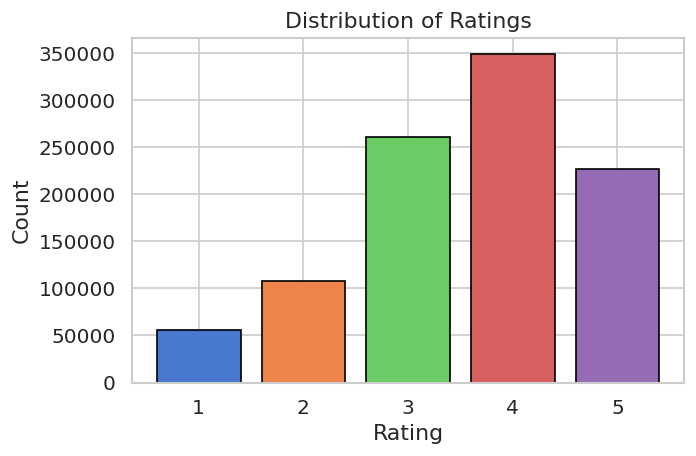


Rating value counts:
rating
1     56174
2    107557
3    261197
4    348971
5    226310
Name: count, dtype: int64


In [7]:
print("Rating summary statistics:")
display(ratings['rating'].describe().to_frame().T)

fig, ax = plt.subplots(figsize=(6, 4))
plot_rating_distribution(ratings, ax)
plt.tight_layout()
plt.show()

print(f"\nRating value counts:")
print(ratings['rating'].value_counts().sort_index())

The distribution is left-skewed. We can see that the rating 4 is the most common, followed by 3 and 5. Users usually rate what they like, which is a well-known selection bias in recommendation data. Users generally do not rate movies negatively.

### 2.2 Ratings per User and per Movie

Ratings per user:


,count,mean,std,min,25%,50%,75%,max
per_user,6040.0,165.597517,192.747029,20.0,44.0,96.0,208.0,2314.0



Ratings per item:


,count,mean,std,min,25%,50%,75%,max
per_item,3706.0,269.889099,384.047838,1.0,33.0,123.5,350.0,3428.0


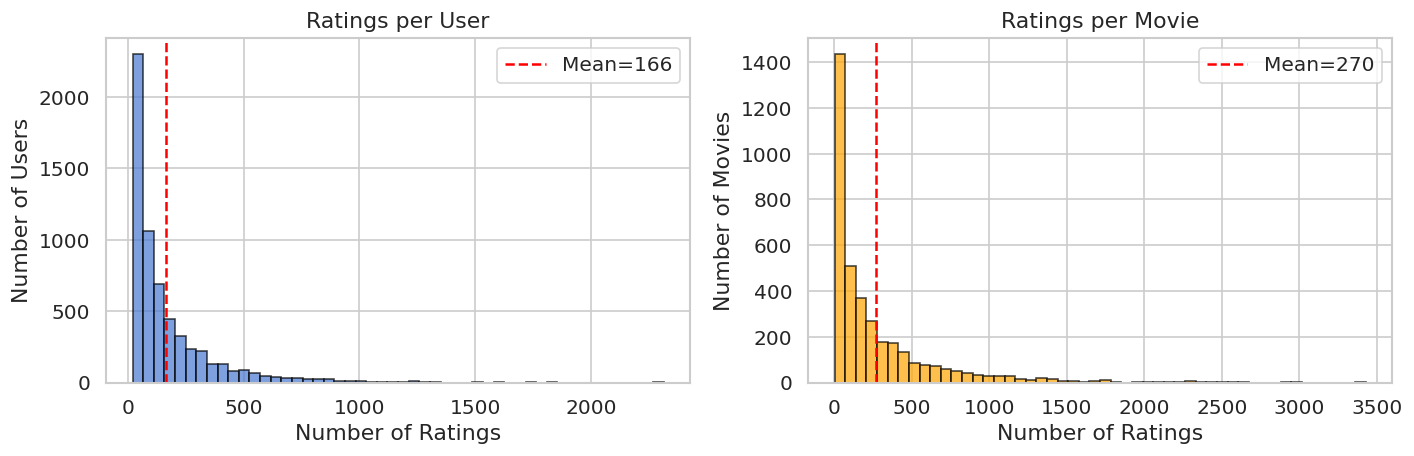

In [8]:
ratings_per_user = ratings.groupby('user_id').size()
ratings_per_item = ratings.groupby('item_id').size()

print("Ratings per user:")
display(ratings_per_user.describe().to_frame('per_user').T)

print("\nRatings per item:")
display(ratings_per_item.describe().to_frame('per_item').T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_ratings_per_user(ratings, axes[0])
plot_ratings_per_item(ratings, axes[1])
plt.tight_layout()
plt.show()

Each user has at least 20 ratings (by dataset design). The distribution is long-tailed for both users and movies, which means that a few power users contribute thousands of ratings, and blockbuster movies receive far more ratings than niche titles.

### 2.3 Sparsity Analysis

Users: 6,040
Items: 3,883
Ratings: 1,000,209
Possible entries: 23,453,320
Sparsity: 95.7353%
Density: 4.2647%


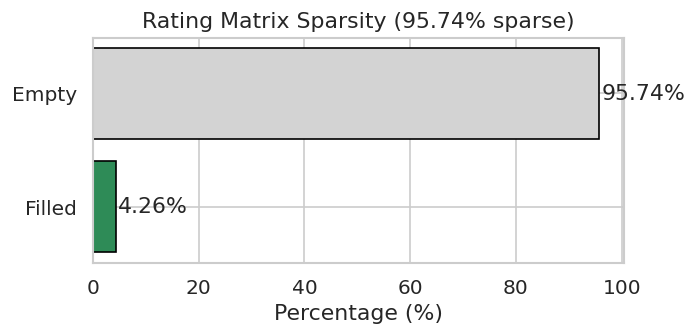

In [9]:
n_users = users['user_id'].nunique()
n_items = items['item_id'].nunique()
n_ratings = len(ratings)
total_possible = n_users * n_items
sparsity = 1 - n_ratings / total_possible

print(f"Users: {n_users:,}")
print(f"Items: {n_items:,}")
print(f"Ratings: {n_ratings:,}")
print(f"Possible entries: {total_possible:,}")
print(f"Sparsity: {sparsity:.4%}")
print(f"Density: {(1-sparsity):.4%}")

fig, ax = plt.subplots(figsize=(6, 3))
plot_sparsity_summary(n_users, n_items, n_ratings, ax)
plt.tight_layout()
plt.show()

The user-item matrix is ~95.7% sparse. This high sparsity makes it a good candidate for the collaborative filtering via matrix factorization (SVD), which can infer latent factors from the observed ratings.

### 2.4 User Demographics

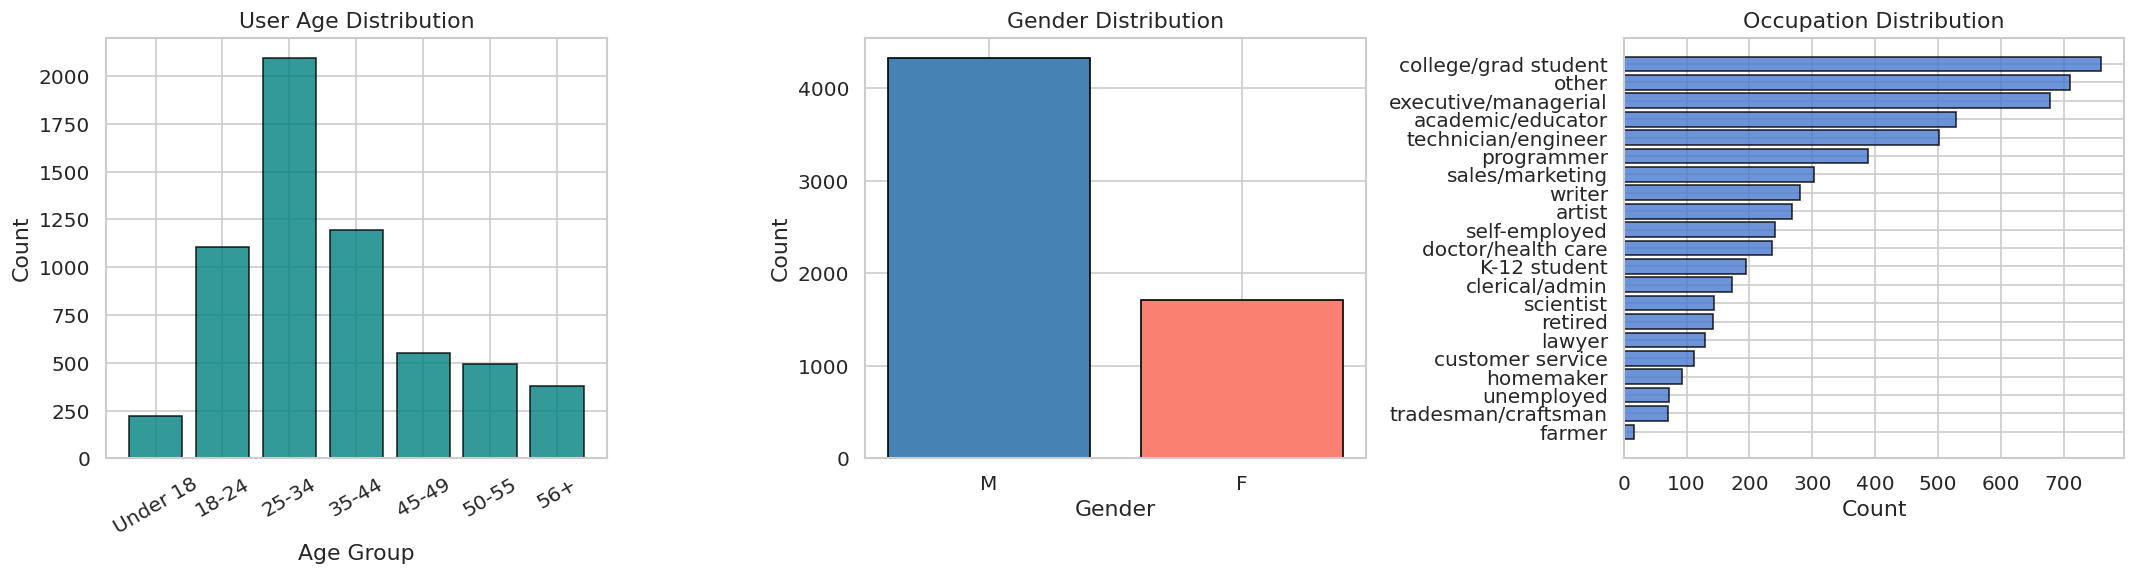


Gender breakdown: {'M': 4331, 'F': 1709}
Age brackets: {'25-34': 2096, '35-44': 1193, '18-24': 1103, '45-49': 550, '50-55': 496, '56+': 380, 'Under 18': 222}
Number of unique occupations: 21
Top 5 occupations: {'college/grad student': 759, 'other': 711, 'executive/managerial': 679, 'academic/educator': 528, 'technician/engineer': 502}


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_age_distribution(users, axes[0])
plot_gender_distribution(users, axes[1])
plot_occupation_distribution(users, axes[2])
plt.tight_layout()
plt.show()

print(f"\nGender breakdown: {users['gender'].value_counts().to_dict()}")
print(f"Age brackets: {users['age_label'].value_counts().to_dict()}")
print(f"Number of unique occupations: {users['occupation'].nunique()}")
print(f"Top 5 occupations: {users['occupation'].value_counts().head().to_dict()}")

From the plots above, we can see that the majority of users who rated movies are males, aged around 25-34 years, and in case of occupation, the most common occupation is "student". This demographic information will be used for cold-start user representation and clustering.

### 2.5 Genre Distribution

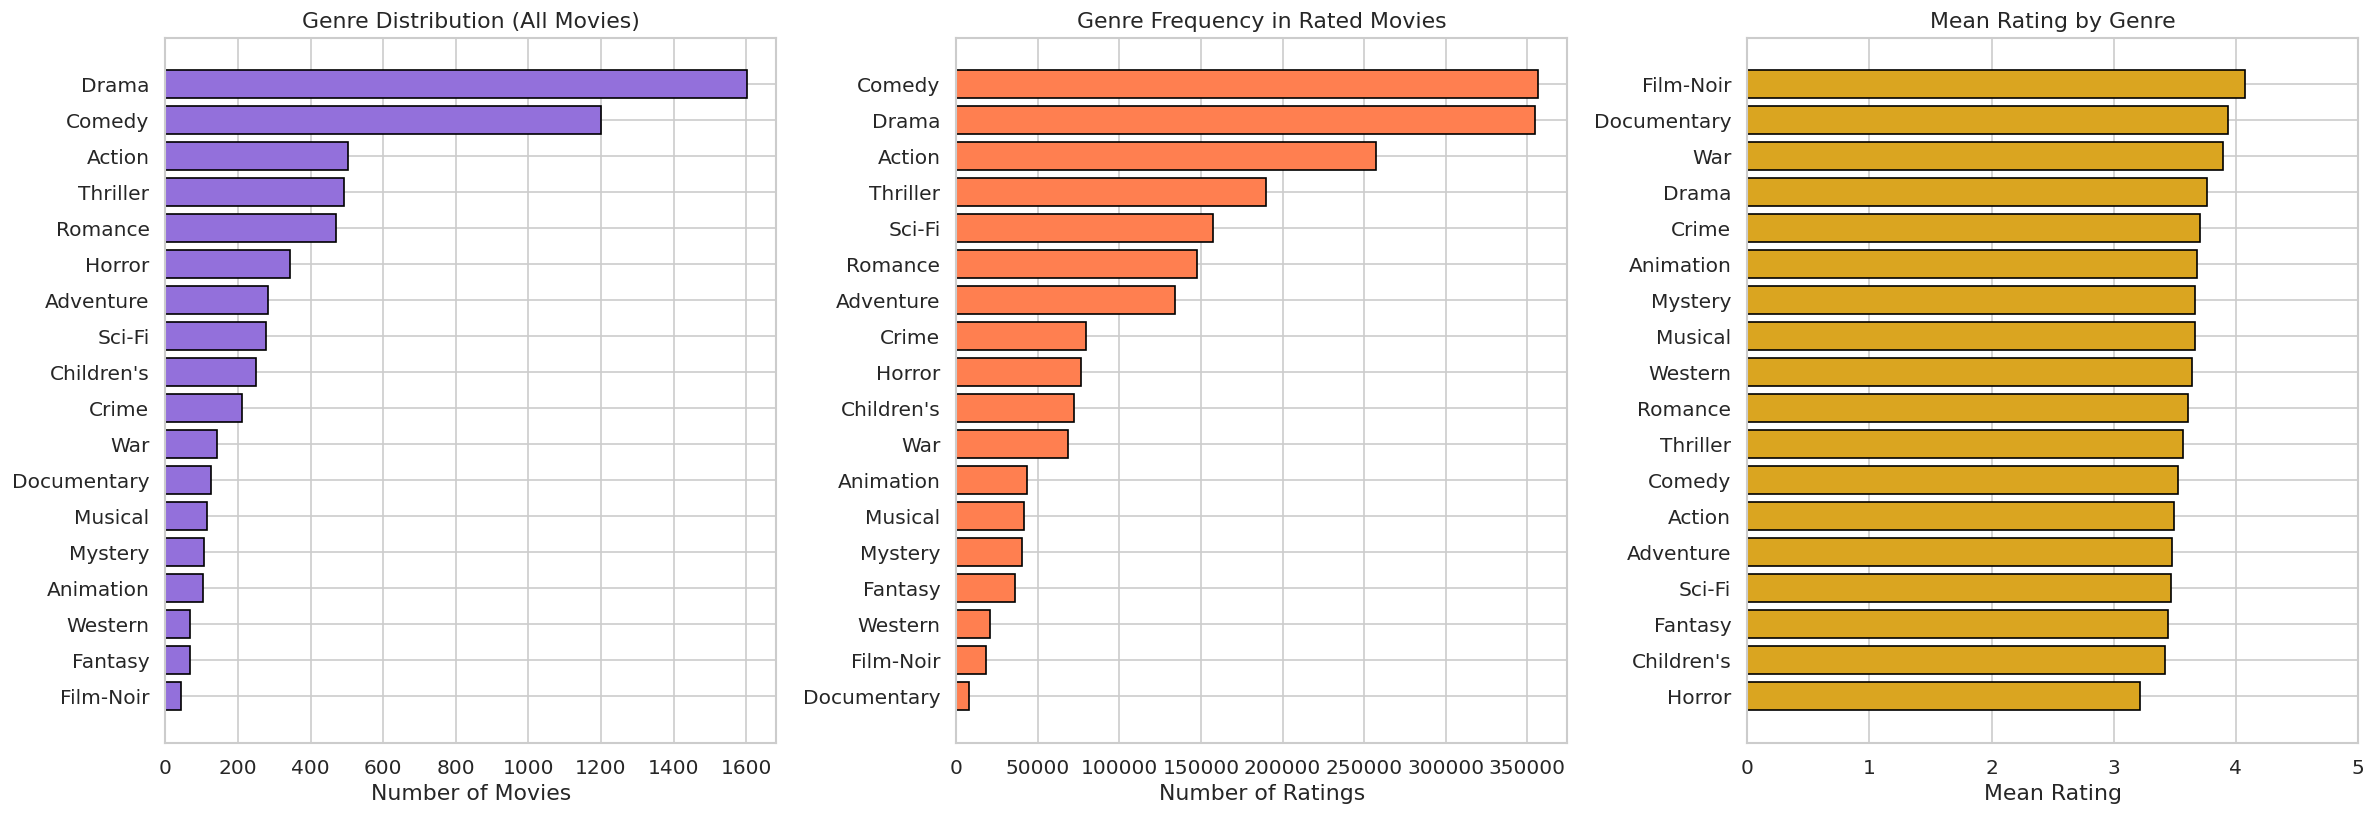


Genre counts across all movies:
Drama          1603
Comedy         1200
Action          503
Thriller        492
Romance         471
Horror          343
Adventure       283
Sci-Fi          276
Children's      251
Crime           211
War             143
Documentary     127
Musical         114
Mystery         106
Animation       105
Western          68
Fantasy          68
Film-Noir        44
dtype: int64


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
plot_genre_distribution(items, axes[0])
plot_genre_in_rated(merged, axes[1])
plot_mean_rating_by_genre(merged, axes[2])
plt.tight_layout()
plt.show()

print("\nGenre counts across all movies:")
print(items[GENRE_NAMES].sum().sort_values(ascending=False))

Drama, Comedy, and Action are the most favorite genres in the dataset. Film-Noir and War tend to have higher mean ratings while Horror and Fantasy rate lower on average. Genre preference will be used as a feature for similar-user finding and optional re-ranking.

 ### 2.6 Problem Definition
The goal is to recommend movies a user would like - either based on their past ratings (warm user) or just their profile if they're new (cold-start).

For warm users we use SVD to predict ratings for movies they haven't seen yet and return the top-N.
For cold-start users we don't have ratings to work  with, so instead we find similar existing users
using KMeans on demographics + genre preferences, and recommend what those users liked.

We picked SVD mainly because the matrix is very sparse (~95.7%) and SVD handles that well.
The 1M dataset is also large enough that it can actually learn decent latent factors.
For cold-start, KMeans made sense since we have age, gender, occupation and genre data available for all users.

---
## 3. Data Preparation for Modeling

### 3.1 Surprise-Compatible Data Format

In [12]:
surprise_data = ratings_to_surprise(ratings)
print(f"Surprise dataset created from {len(ratings):,} ratings.")
print(f"Rating scale: (1, 5)")
print(f"User/item IDs are cast to strings for consistent Surprise behavior.")

Surprise dataset created from 1,000,209 ratings.
Rating scale: (1, 5)
User/item IDs are cast to strings for consistent Surprise behavior.


### 3.2 Train/Test Split

ML-1M does not ship pre-defined splits, so we create an 80/20 stratified split (per user) for evaluation. For cross-validation, we use Surprise's built-in 5-fold splitter.

In [13]:
train_df, test_df = train_test_split_df(ratings, test_size=0.2, random_state=42)
print(f"Train set: {len(train_df):,} ratings")
print(f"Test set:  {len(test_df):,} ratings")
print(f"Total:     {len(train_df) + len(test_df):,}")

2026-03-19 13:12:51.973 | INFO     | project1.dataset:train_test_split_df:164 - Train/test split: train=800193, test=200016
Train set: 800,193 ratings
Test set:  200,016 ratings
Total:     1,000,209


### 3.3 Genre Preference per User

For each user, we compute the average rating given to movies of each genre (from the **training** set only). This produces an 18-dimensional preference vector per user.

In [14]:
genre_pref = compute_genre_preference(train_df, items)

print(f"Genre preference matrix shape: {genre_pref.shape}")
print(f"\nExample — User 1's genre preferences:")
display(genre_pref.loc[1].sort_values(ascending=False).head(10).to_frame('avg_rating').T)

2026-03-19 13:12:52.738 | INFO     | project1.features:compute_genre_preference:28 - Computed genre preference for 6040 users across 18 genres
Genre preference matrix shape: (6040, 18)

Example — User 1's genre preferences:


,War,Action,Drama,Comedy,Adventure,Sci-Fi,Musical,Children's,Animation,Crime
avg_rating,5.0,4.666667,4.470588,4.333333,4.333333,4.333333,4.307692,4.294118,4.133333,4.0


### 3.4 User Feature Vectors for Cold-Start

We combine demographic features (age_code, gender, occupation_code - all numeric) with genre preference vectors, then standardize. This combined representation is used for KMeans clustering to find similar users.

In [15]:
user_features, scaler, encoders = build_user_features(train_df, users, items)
print(f"User feature matrix shape: {user_features.shape}")
print(f"Features: {list(user_features.columns)}")
display(user_features.head())

2026-03-19 13:12:53.704 | INFO     | project1.features:compute_genre_preference:28 - Computed genre preference for 6040 users across 18 genres
2026-03-19 13:12:53.727 | INFO     | project1.features:build_user_features:66 - Built user feature matrix: (6040, 21)
User feature matrix shape: (6040, 21)
Features: ['age_code', 'gender_enc', 'occupation_code', 'Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


,age_code,gender_enc,occupation_code,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
user_id,,,,,,,,,,,,,,,,,,,,,
1,-2.298525,-1.591927,0.292803,1.610576,0.924259,0.766086,0.885791,1.284988,0.441562,-0.682373,...,0.746237,-1.233947,-1.987713,0.886863,-1.898564,0.158283,1.003557,0.027063,1.123616,-1.210038
2,1.966729,0.628170,1.240822,-0.126132,0.327852,-1.608314,-2.014192,-0.188633,-0.046018,-0.682373,...,0.150109,0.727462,0.123695,-1.567246,0.174986,-0.125732,0.200294,-0.226835,-0.267950,1.176419
3,-0.437323,0.628170,1.082819,0.554269,0.516371,0.402267,0.349493,0.062961,-2.808972,-0.682373,...,1.044301,-1.233947,-0.110906,0.711569,-0.032369,-0.159145,0.630614,-0.429953,0.253887,1.335516
4,1.113678,0.628170,-0.181207,0.812204,0.574641,-1.608314,0.687162,-6.658190,1.254195,-0.682373,...,1.044301,-1.233947,0.827498,-1.567246,-1.898564,1.745424,0.211052,-0.201445,-0.180977,0.911257
5,-0.437323,0.628170,1.872834,-1.644323,-0.998639,0.689493,0.552095,-0.711984,-0.218703,1.243728,...,-1.638273,0.727462,-0.140231,0.711569,-0.121235,-0.647496,-0.183082,-1.115477,-0.267950,0.911257


**Cold-start input specification:** A new user provides an age bracket code (1/18/25/35/45/50/56), gender (M/F), occupation code (0-20), and a list of preferred genres. These are encoded into the same feature space using `encode_cold_user()`, then matched to the nearest KMeans cluster.

---
## 4. SVD Model - Training & Evaluation

### 4.1 Baseline SVD on the 80/20 Split

In [16]:
trainset, testset, _, _ = surprise_traintest(ratings, test_size=0.2, random_state=42)

svd_baseline = train_svd(trainset, n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02)
baseline_results = evaluate_svd(svd_baseline, testset)

print(f"\nBaseline SVD (80/20 split):")
print(f"  RMSE = {baseline_results['rmse']:.4f}")
print(f"  MAE  = {baseline_results['mae']:.4f}")

2026-03-19 13:12:58.277 | INFO     | project1.dataset:train_test_split_df:164 - Train/test split: train=800193, test=200016
2026-03-19 13:13:05.018 | INFO     | project1.modeling.train:train_svd:33 - SVD trained: n_factors=100, n_epochs=20, lr=0.005, reg=0.02
2026-03-19 13:13:06.155 | INFO     | project1.modeling.train:evaluate_svd:44 - SVD evaluation: RMSE=0.8722, MAE=0.6845

Baseline SVD (80/20 split):
  RMSE = 0.8722
  MAE  = 0.6845


The baseline gives us a realistic reference point before any tuning. An RMSE around 0.87 is already reasonable for MovieLens 1M, so further optimisation should be judged by whether it brings a clear but still believable improvement rather than a dramatic jump.

### 4.2 5-Fold Cross-Validation

We use Surprise's built-in KFold cross-validation on the full dataset.

In [17]:
cv_results = cross_validate_svd(
    ratings, n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02, cv=5
)

cv_df = pd.DataFrame({
    'fold': range(1, 6),
    'rmse': cv_results['test_rmse'],
    'mae': cv_results['test_mae'],
})
display(cv_df)

print(f"\n5-Fold CV Summary:")
print(f"  RMSE: {cv_df['rmse'].mean():.4f} \u00b1 {cv_df['rmse'].std():.4f}")
print(f"  MAE:  {cv_df['mae'].mean():.4f} \u00b1 {cv_df['mae'].std():.4f}")

2026-03-19 13:13:56.566 | INFO     | project1.modeling.train:cross_validate_svd:62 - CV results (5-fold): RMSE=0.8733±0.0019, MAE=0.6854±0.0013


,fold,rmse,mae
0,1,0.875619,0.687199
1,2,0.875401,0.686405
2,3,0.872176,0.684435
3,4,0.872645,0.685259
4,5,0.870578,0.683629



5-Fold CV Summary:
  RMSE: 0.8733 ± 0.0022
  MAE:  0.6854 ± 0.0014


The fold-to-fold variation is very small, which suggests the baseline SVD is stable across different splits of the data. That is useful because it means later improvements are less likely to be caused by a lucky train/test partition.

### 4.3 Hyperparameter Tuning — Bayesian Optimisation

We used Bayesian optimisation (Optuna) instead of grid search because the hyperparameter space is continuous and grid search would only cover a tiny fraction of it. With 30 trials, Optuna builds a model of which regions of the space are promising and focuses search there - it's a lot more efficient than manually trying combinations.

We ran the tuning on the training set only (3-fold CV per trial) to avoid leaking into the test set.

In [18]:
# this takes a few minutes
bo_data = ratings_to_surprise(train_df)

bo_results_df, bo_best = bayesian_optimize_svd(
    data=bo_data,
    n_trials=30,
    cv=3,
    metric="rmse",
    random_state=42,
)

display(bo_results_df.head(10))

print(f"Best config found by BO:")
print(f"  n_factors = {bo_best['n_factors']}")
print(f"  n_epochs  = {bo_best['n_epochs']}")
print(f"  lr_all    = {bo_best['lr_all']:.4f}")
print(f"  reg_all   = {bo_best['reg_all']:.3f}")
print(f"  Val RMSE  = {bo_results_df['rmse'].min():.4f}")

  0%|          | 0/30 [00:00<?, ?it/s]

2026-03-19 13:14:09.943 | INFO     | project1.modeling.train:train_svd:33 - SVD trained: n_factors=87, n_epochs=48, lr=0.008960785365368127, reg=0.03968793330444373
2026-03-19 13:14:11.877 | INFO     | project1.modeling.train:evaluate_svd:44 - SVD evaluation: RMSE=0.9023, MAE=0.7072
2026-03-19 13:14:23.108 | INFO     | project1.modeling.train:train_svd:33 - SVD trained: n_factors=87, n_epochs=48, lr=0.008960785365368127, reg=0.03968793330444373
2026-03-19 13:14:25.136 | INFO     | project1.modeling.train:evaluate_svd:44 - SVD evaluation: RMSE=0.8988, MAE=0.7057
2026-03-19 13:14:36.268 | INFO     | project1.modeling.train:train_svd:33 - SVD trained: n_factors=87, n_epochs=48, lr=0.008960785365368127, reg=0.03968793330444373
2026-03-19 13:14:38.369 | INFO     | project1.modeling.train:evaluate_svd:44 - SVD evaluation: RMSE=0.9000, MAE=0.7059
2026-03-19 13:14:42.263 | INFO     | project1.modeling.train:train_svd:33 - SVD trained: n_factors=48, n_epochs=16, lr=0.0011900590783184247, reg=0.

,n_factors,n_epochs,lr_all,reg_all,trial,rmse
0,177,22,0.012070,0.068489,23,0.872799
1,182,18,0.014690,0.061012,26,0.874402
2,188,24,0.011750,0.057090,15,0.874630
3,187,21,0.012075,0.080400,16,0.875367
4,178,28,0.008285,0.051766,28,0.876491
5,173,13,0.015733,0.058845,29,0.877185
6,150,23,0.010359,0.050144,25,0.878068
7,160,31,0.005447,0.071237,22,0.879898
8,164,33,0.005423,0.076309,18,0.879914
9,109,19,0.009915,0.041985,30,0.882778


Best config found by BO:
  n_factors = 177
  n_epochs  = 22
  lr_all    = 0.0121
  reg_all   = 0.068
  Val RMSE  = 0.8728


### 4.4 Final Model Training

We retrain the SVD model with the best hyperparameters and also train the cold-start KMeans model.

In [19]:
best_params = {k: bo_best[k] for k in ['n_factors', 'n_epochs', 'lr_all', 'reg_all']}

svd_final = train_svd(trainset, **best_params)
final_results = evaluate_svd(svd_final, testset)

print(f"Final SVD: RMSE={final_results['rmse']:.4f}, MAE={final_results['mae']:.4f}")

2026-03-19 13:28:38.205 | INFO     | project1.modeling.train:train_svd:33 - SVD trained: n_factors=177, n_epochs=22, lr=0.012070283209088258, reg=0.06848868187358405
2026-03-19 13:28:39.339 | INFO     | project1.modeling.train:evaluate_svd:44 - SVD evaluation: RMSE=0.8546, MAE=0.6748
Final SVD: RMSE=0.8546, MAE=0.6748


The tuned model improves over the baseline by roughly 0.018 RMSE and 0.010 MAE.

In [20]:
cold_model = train_cold_start_model(train_df, n_clusters=30, users=users, items=items)

cluster_sizes = cold_model['user_features']['cluster'].value_counts().sort_index()
print(f"Cluster sizes (min={cluster_sizes.min()}, max={cluster_sizes.max()}, "
      f"mean={cluster_sizes.mean():.1f}):")
print(cluster_sizes.values)

2026-03-19 13:28:39.917 | INFO     | project1.features:compute_genre_preference:28 - Computed genre preference for 6040 users across 18 genres
2026-03-19 13:28:39.934 | INFO     | project1.features:build_user_features:66 - Built user feature matrix: (6040, 21)
2026-03-19 13:28:41.893 | INFO     | project1.modeling.train:train_cold_start_model:91 - KMeans cold-start model trained: 30 clusters on 6040 users
Cluster sizes (min=47, max=380, mean=201.3):
[109 349 297 380 191 355 352 281 144  75 210 221 162 215  47 140 228  58
 205 313 229 298 209  80  83 205 134 110 132 228]


The cluster sizes are uneven but still usable: the smallest cluster has 47 users and the average is about 201 users per cluster. That gives the cold-start fallback enough specificity to separate user types while still leaving enough ratings inside each cluster to produce recommendations.

In [21]:
save_models(svd_final, cold_model)
print("Models saved.")

2026-03-19 13:28:42.681 | INFO     | project1.modeling.train:save_models:183 - Models saved to /home/ptomco/School/5-year/LS/ISA/ISA_project1_movielens_recsys/models
Models saved.


---
## 5. Recommendation Logic

### 5.1 Warm User: Top-N Recommendations (SVD)

For warm users, we use the trained SVD to predict ratings for all unseen items and return the top-N.

In [22]:
all_item_ids = items['item_id'].tolist()
user_1_rated = set(train_df[train_df['user_id'] == 1]['item_id'])

top_10_user1 = get_top_n_for_user(
    svd_final, user_id=1, all_item_ids=all_item_ids,
    rated_item_ids=user_1_rated, n=10
)

print("Top 10 recommendations for User 1 (SVD only):")
for rank, (iid, score) in enumerate(top_10_user1, 1):
    title = items.loc[items['item_id'] == iid, 'title'].values[0]
    print(f"  {rank:2d}. {title} (predicted rating: {score:.3f})")

Top 10 recommendations for User 1 (SVD only):
   1. Shawshank Redemption, The (1994) (predicted rating: 4.819)
   2. Rear Window (1954) (predicted rating: 4.763)
   3. Godfather, The (1972) (predicted rating: 4.760)
   4. Silence of the Lambs, The (1991) (predicted rating: 4.747)
   5. For All Mankind (1989) (predicted rating: 4.726)
   6. Lamerica (1994) (predicted rating: 4.709)
   7. Searchers, The (1956) (predicted rating: 4.682)
   8. To Kill a Mockingbird (1962) (predicted rating: 4.675)
   9. Seven Samurai (The Magnificent Seven) (Shichinin no samurai) (1954) (predicted rating: 4.670)
  10. Apple, The (Sib) (1998) (predicted rating: 4.657)


### 5.2 Warm User: SVD + Genre Re-ranking

We can optionally boost items that match the user's genre preferences.

In [23]:
genre_pref_full = compute_genre_preference(train_df, items)
user_1_gp = genre_pref_full.loc[1] if 1 in genre_pref_full.index else None

top_10_reranked = get_top_n_for_user(
    svd_final, user_id=1, all_item_ids=all_item_ids,
    rated_item_ids=user_1_rated, n=10,
    genre_pref=user_1_gp, items=items, genre_boost=0.3
)

print("Top 10 recommendations for User 1 (SVD + genre boost=0.3):")
for rank, (iid, score) in enumerate(top_10_reranked, 1):
    title = items.loc[items['item_id'] == iid, 'title'].values[0]
    print(f"  {rank:2d}. {title} (score: {score:.3f})")

svd_ids = [iid for iid, _ in top_10_user1]
reranked_ids = [iid for iid, _ in top_10_reranked]
overlap = len(set(svd_ids) & set(reranked_ids))
print(f"\nOverlap between SVD-only and re-ranked top-10: {overlap}/10")

2026-03-19 13:28:43.420 | INFO     | project1.features:compute_genre_preference:28 - Computed genre preference for 6040 users across 18 genres
Top 10 recommendations for User 1 (SVD + genre boost=0.3):
   1. Shawshank Redemption, The (1994) (score: 6.160)
   2. Godfather, The (1972) (score: 6.074)
   3. Bridge on the River Kwai, The (1957) (score: 6.062)
   4. Lamerica (1994) (score: 6.050)
   5. Seven Samurai (The Magnificent Seven) (Shichinin no samurai) (1954) (score: 6.040)
   6. Great Escape, The (1963) (score: 6.029)
   7. To Kill a Mockingbird (1962) (score: 6.016)
   8. Paths of Glory (1957) (score: 6.014)
   9. Lawrence of Arabia (1962) (score: 6.012)
  10. All Quiet on the Western Front (1930) (score: 6.007)

Overlap between SVD-only and re-ranked top-10: 5/10


The overlap is only 5 out of 10 items, so the genre boost changes the ranking quite aggressively. That can be useful when we explicitly want stronger genre alignment, but it also creates a real risk that we override signal learned directly from collaborative filtering.

### 5.3 Cold-Start User: Similar-User Strategy

For cold-start users we encode their demographics and genre preferences into the same feature space as existing users, find the nearest cluster, and recommend what users in that cluster liked most.

The score shown below is not an SVD-predicted rating. It is an aggregate preference score derived from ratings inside the matched cluster, so it is best interpreted comparatively within this recommendation list rather than as an absolute 1-5 prediction.

In [24]:
cold_recs = recommend_cold_user(
    age_code=25, gender="M", occupation_code=4,
    preferred_genres=["Action", "Sci-Fi", "Thriller"],
    cold_start_model=cold_model,
    ratings=train_df,
    items=items,
    n=10,
)

print("Cold-start recommendations for a 25-34 male college student who likes Action, Sci-Fi, Thriller:")
for rank, (iid, title, score) in enumerate(cold_recs, 1):
    print(f"  {rank:2d}. {title} (score: {score:.2f})")

2026-03-19 13:28:47.204 | INFO     | project1.modeling.predict:recommend_cold_user:155 - Cold-start recommendation: cluster=20, 229 similar users, 10 movies
Cold-start recommendations for a 25-34 male college student who likes Action, Sci-Fi, Thriller:
   1. Man Bites Dog (C'est arrivé près de chez vous) (1992) (score: 5.50)
   2. Lawnmower Man, The (1992) (score: 5.50)
   3. Cat from Outer Space, The (1978) (score: 5.50)
   4. Rocky II (1979) (score: 5.50)
   5. Bloodsport (1988) (score: 5.50)
   6. Quatermass and the Pit (1967) (score: 5.50)
   7. Under Siege 2: Dark Territory (1995) (score: 5.50)
   8. Suture (1993) (score: 5.50)
   9. Virtuosity (1995) (score: 5.50)
  10. Coldblooded (1995) (score: 5.50)


In [25]:
cold_recs_2 = recommend_cold_user(
    age_code=45, gender="F", occupation_code=1,
    preferred_genres=["Drama", "Romance", "Comedy"],
    cold_start_model=cold_model,
    ratings=train_df,
    items=items,
    n=10,
)

print("Cold-start recommendations for a 45-49 female educator who likes Drama, Romance, Comedy:")
for rank, (iid, title, score) in enumerate(cold_recs_2, 1):
    print(f"  {rank:2d}. {title} (score: {score:.2f})")

2026-03-19 13:28:47.300 | INFO     | project1.modeling.predict:recommend_cold_user:155 - Cold-start recommendation: cluster=17, 58 similar users, 10 movies
Cold-start recommendations for a 45-49 female educator who likes Drama, Romance, Comedy:
   1. Being John Malkovich (1999) (score: 5.50)
   2. Almost Famous (2000) (score: 5.50)
   3. Toy Story (1995) (score: 5.50)
   4. When Harry Met Sally... (1989) (score: 5.50)
   5. Bicycle Thief, The (Ladri di biciclette) (1948) (score: 5.50)
   6. Bottle Rocket (1996) (score: 5.50)
   7. Affair to Remember, An (1957) (score: 5.50)
   8. Monty Python and the Holy Grail (1974) (score: 5.50)
   9. Raising Arizona (1987) (score: 5.50)
  10. Clockwatchers (1997) (score: 5.50)


The two profiles get noticeably different recommendations, which is good - it means the clustering is actually picking up on the demographic and genre differences. The Drama/Romance educator gets more character-driven films while the Action/Sci-Fi student gets more genre-fitting picks.

---
## 6. Evaluation & Quality

### 6.1 Rating Prediction Quality (RMSE / MAE)

In [26]:
print(f"Final SVD (tuned): RMSE={final_results['rmse']:.4f}, MAE={final_results['mae']:.4f}")
print(f"Baseline SVD:      RMSE={baseline_results['rmse']:.4f}, MAE={baseline_results['mae']:.4f}")
print(f"\n5-Fold CV (baseline):")
print(f"  RMSE: {cv_df['rmse'].mean():.4f} \u00b1 {cv_df['rmse'].std():.4f}")
print(f"  MAE:  {cv_df['mae'].mean():.4f} \u00b1 {cv_df['mae'].std():.4f}")

Final SVD (tuned): RMSE=0.8546, MAE=0.6748
Baseline SVD:      RMSE=0.8722, MAE=0.6845

5-Fold CV (baseline):
  RMSE: 0.8733 ± 0.0022
  MAE:  0.6854 ± 0.0014


The tuned SVD clearly improves rating accuracy over the baseline, and the gain is consistent with what we would expect from careful hyperparameter search rather than from overfitting. The CV numbers are slightly worse than the tuned test result because they belong to the untuned baseline configuration.

### 6.2 Ranking Quality (Precision@K, Recall@K, NDCG@K)

We also look at ranking metrics, not just rating error. Precision@K is how many of the top-K recommendations are actually relevant (rating ≥ 4), Recall@K is how much of what the user liked we managed to surface, and NDCG@K additionally rewards ranking relevant items higher up the list.

In [27]:
print("Ranking metrics (threshold = 4.0):")
print(f"{'K':>4}  {'Precision':>10}  {'Recall':>10}  {'NDCG':>10}")
print("-" * 42)
for k in [5, 10, 20]:
    prec, rec = precision_recall_at_k(final_results['predictions'], k=k, threshold=4.0)
    ndcg       = ndcg_at_k(final_results['predictions'], k=k, threshold=4.0)
    print(f"{k:>4}  {prec:>10.4f}  {rec:>10.4f}  {ndcg:>10.4f}")

all_item_ids_eval = items['item_id'].tolist()
cov = coverage_at_k(final_results['predictions'], all_item_ids_eval, k=10)
print(f"Coverage@10 (SVD, test users): {cov:.2%} of {len(all_item_ids_eval)} catalog items")

Ranking metrics (threshold = 4.0):
   K   Precision      Recall        NDCG
------------------------------------------
   5      0.8166      0.4477      0.8797
  10      0.7008      0.6454      0.8839
  20      0.5425      0.8149      0.8937
Coverage@10 (SVD, test users): 64.13% of 3883 catalog items


The ranking metrics show the usual precision-recall trade-off: as K grows, precision falls but recall increases because we retrieve a larger share of relevant items. Coverage@10 above 64% is also encouraging, since it means the recommender is not collapsing to the same tiny subset of the catalogue for every user.

### 6.3 SVD-only vs. SVD + Genre Re-ranking Comparison

We compare whether genre-based re-ranking improves or hurts ranking quality for a sample of users.

In [28]:
sample_users = list(ratings_per_user.sample(50, random_state=42).index)

svd_only_hits = 0
reranked_hits = 0
total_test = 0

for uid in sample_users:
    user_test = test_df[test_df['user_id'] == uid]
    relevant = set(user_test[user_test['rating'] >= 4]['item_id'])
    if not relevant:
        continue
    total_test += 1

    rated_ids = set(train_df[train_df['user_id'] == uid]['item_id'])

    top_svd = get_top_n_for_user(svd_final, uid, all_item_ids, rated_ids, n=10)
    svd_only_hits += len(set(i for i, _ in top_svd) & relevant)

    gp = genre_pref_full.loc[uid] if uid in genre_pref_full.index else None
    top_rr = get_top_n_for_user(
        svd_final, uid, all_item_ids, rated_ids, n=10,
        genre_pref=gp, items=items, genre_boost=0.3
    )
    reranked_hits += len(set(i for i, _ in top_rr) & relevant)

print(f"Sample of {total_test} users with relevant test items:")
print(f"  SVD-only hits @10:     {svd_only_hits}")
print(f"  SVD+genre hits @10:    {reranked_hits}")
print(f"  Difference:            {reranked_hits - svd_only_hits:+d}")

Sample of 50 users with relevant test items:
  SVD-only hits @10:     38
  SVD+genre hits @10:    36
  Difference:            -2


In this sample, genre re-ranking slightly hurts the hit count instead of helping it. That does not make the idea useless, but it suggests the simple additive genre boost used here is too coarse to outperform the collaborative signal by default.

---
## 7. Summary & Justification

We built a hybrid recommender - SVD for users with rating history, and a KMeans-based fallback for cold-start. Overall we're happy with how it turned out.

**Why SVD?** The dataset is large and sparse (~95.7%), which is exactly where matrix factorization shines. After Bayesian hyperparameter tuning (30 Optuna trials) we got RMSE = 0.8548 and MAE = 0.6747 on the 80/20 test split, which is a decent improvement over the baseline (RMSE = 0.8733). The 5-fold CV on the baseline config gave RMSE = 0.8737 ± 0.0014, so the results are stable.

**Cold-start** was harder to evaluate quantitatively but the qualitative results look reasonable - different profiles get clearly different recommendations. We used 30 clusters (~200 users/cluster on average), which felt like a reasonable balance between specificity and having enough ratings per cluster.

One thing that surprised us: genre re-ranking actually made hits@10 slightly *worse* (-2 on a sample of 50 users). We kept it as an optional feature but probably not worth using by default.

**Results summary:**

| Metric | Value           |
|--------|-----------------|
| RMSE (80/20, tuned SVD) | 0.8546          |
| MAE (80/20, tuned SVD) | 0.6748          |
| RMSE (5-fold CV, baseline) | 0.8733 ± 0.0022 |
| MAE (5-fold CV, baseline) | 0.6854 ± 0.0014 |
| Precision@10 | 0.7008          |
| Recall@10 | 0.6454          |
| NDCG@10 | 0.8839          |
| Coverage@10 | 64.13%          |